# Bio-Argo match-ups
**Author:** Eli Holmes (NOAA)</br>
Last updated: November 21, 2025

We have upwards of 33k bbp700 and 10k chl-a points for the global bio-Argo data. The goal is to get the Rrs data, all bands, for each of these. However, with so many points we need to be careful with memory. Just opening the meta-data for all the Rrs files, 500+ days since March 2024, will eat up a lot of memory.

**What do we do?**

1. When we open the PACE Rrs files, we create `ds` with `chunks{}` so that dask knows the chunk structure and will not try to load the whole file.
2. We compute the vector of indices for the Argo points and use `ds.vindex([vector_i, vector_j)`. That will load only the needed chunks.
3. We work through the files in batches rather than one massive for loop. This will keep the memory from exploding on us as we open files.


## Load the Argo profile data

This is the lat/lon/time data for every profile we have from Mar 2024 to Nov 2025. We will use this information to find matching Rrs, Kd, and chlor_a data from PACE.

In [2]:
# Load data from GitHub
df_y_name="CHLA"; df_lat_name="LATITUDE"; df_lon_name="LONGITUDE"; df_time_name="TIME"
import pandas as pd
base_url="https://raw.githubusercontent.com/fish-pace/2025-tutorials/main/data/argo_monthly_nc/"
url = f"{base_url}argo_profiles_index.parquet"
argo_chl_df = pd.read_parquet(url)
len(argo_chl_df)

15792

## Load custom functions

In [3]:
# --- Custom python functions ---
import os, importlib
# Looks to see if you have the file already and if not, downloads from GitHub
if not os.path.exists("ml_utils.py"):
    !wget -q https://raw.githubusercontent.com/fish-pace/2025-tutorials/main/ml_utils.py

import ml_utils as mu
importlib.reload(mu)

<module 'ml_utils' from '/home/jovyan/2025-tutorials/ml_utils.py'>

# Workflow to process one PACE file

Assume:

* The files are for a regular grid, i.e. level 3 data
* The files do not have a time coordinate. This is how the PACE level 3 daily and 8-day files are currently structured.
* We are looking at a variable, like Rrs, that has a 3rd dimension of wavelength or similar. Usually called wavelength or wavelength_3d. So the dims are (lat, lon, 3rd dim)
* `time_coverage_start` and `time_coverage_end` exist as attributes in the files.
* `ds[ds_vec_name]` is a 1D coordinate aligned with the last dimension of ds_var_name.

Process Steps:

1.  Subset our Argo dataframe to only those rows within in the  time window covered by the cloud-hosted xarray dataset (`ds`). Let's call that `df_day`
2.  Get the lat/lon indices of `ds` that correspond to the lat/lon rows in `df_day`. These indices will look like `[0, 3, 6]` and `[0, 10, 15]` corresponding to index pairs, like `(3, 10)` corresponding to the lat/lon pair in a row of `df_day`.
3.  Do a fast point retrieval from `ds`. `ds` is cloud optimized (chunked) file and we only want to the chunks that we need. We do not need to load all the chunks. I/O of cloud-hosted data is the slow part so don't touch more of the data than you need to.
4. Build a dataframe with the predictor variables that we want from `ds`.

In [31]:
## The function to process one file is in ml_utils.py
help(mu.one_file_matches)

Help on function one_file_matches in module ml_utils:

one_file_matches(f: 'earthaccess.store.EarthAccessFile', df: pandas.core.frame.DataFrame, ds_lat_name: str = 'lat', ds_lon_name: str = 'lon', ds_time_name: str = 'time', ds_vec_name: Optional[str] = 'wavelength', ds_var_name: str = 'Rrs', ds_vec_sel=None, df_lat_name: str = 'lat', df_lon_name: str = 'lon', df_time_name: str = 'time') -> Tuple[Optional[pandas.core.frame.DataFrame], Optional[pandas.core.frame.DataFrame]]
        Match Argo point observations to a single PACE L2/L3 file and extract
        colocated satellite values and metadata.
    
        Parameters
        ----------
        f : file-like object
            An earthaccess/open file-like handle for a single PACE granule
            (as returned by `earthaccess.open`). This object is passed directly
            to `xr.open_dataset` to read the granule.
        df : pandas.DataFrame
            A DataFrame containing Argo observations. Must include columns for
     

## Run through the PACE files in batches

Just in case something hangs.

### Workflow

* Create a function to get all matches for one PACE file `one_file_matches()`
* Create a function to run a batch of PACE files `run_batch()`
* Do a for loop over our batches and run `run_batch()` on each
* Gather results into one file

We will run for all PACE files that we have. Later when we match to the Argo profiles, we can choose the best PACE data, e.g. only use NRT data if that is all that is available.

### `run_batch()` function

* Run `mu.one_file_matches()` on each file
* Save results from the batch to a file in case the process crashes
* Later we will reconstruct from the batch files. The files are small.

In [4]:
%%time
from datetime import datetime

def run_batch(
    results, df, 
    ds_vec_name="wavelength", ds_var_name="Rrs", ds_vec_sel=None,
    df_time_name="TIME", df_lat_name="LATITUDE", df_lon_name="LONGITUDE"
):
    """
    Run a batch of PACE files (results) and return PACE variables for lat/lon/time rows in a
    dataframe.

    Parameters
    ----------
    results : earthaccess results object as returned by `earthaccess.search`). 
    
    df : A pandas DataFrame containing Argo observations. Must include columns for
        time, latitude, longitude.

    ds_vec_name : str or None, optional
        Name of the spectral dimension in the PACE dataset (e.g. "wavelength").
        If not None, matched satellite spectra are returned with one column per
        wavelength. If None, only a single variable is extracted.

    ds_vec_sel : value or None, optional
        Value of the spectral dimension in the PACE dataset (e.g. "wavelength")
        to select. If None, matched satellite spectra are returned with one column per
        wavelength. If given, only a single variable is extracted for that value.

    ds_var_name : str, optional
        Name of the variable to extract from the PACE dataset
        (e.g. "Rrs" or "chlor_a").

    df_lat_name, df_lon_name, df_time_name : str, optional
        Column names in `df` for latitude, longitude, and time.
    """

    # Make sure to refresh fileset to minimize the chance that the token expires before we are done
    # this for loop consumes about 6Gb of RAM
    fileset = earthaccess.open(results, pqdm_kwargs={"disable": True} );
    
    df_plus = []
    for i, f in enumerate(fileset):
        df_record, pts = mu.one_file_matches(
            f, df, 
            ds_vec_name=ds_vec_name, ds_var_name=ds_var_name, ds_vec_sel=ds_vec_sel,
            df_time_name=df_time_name, df_lat_name=df_lat_name, df_lon_name=df_lon_name)
        if df_record is None or len(df_record) == 0: 
            print(f"Skipped day {i} no data in df")
            continue
        # error check
        if len(df_record) != len(pts):
            raise ValueError(f"Row mismatch: df_record={len(df_record)}, pts={len(pts)}")
    
        # left "concat": keep df_record rows, add pts columns by position
        df_record_plus = pd.concat(
            [ 
                df_record.reset_index(drop=True), 
                pts.reset_index(drop=True),
            ], axis=1,)
        df_plus.append(df_record_plus)
    if not len(df_plus) == 0:
        df_plus = pd.concat(df_plus, ignore_index=True)
    return df_plus

CPU times: user 12 μs, sys: 1e+03 ns, total: 13 μs
Wall time: 16.5 μs


## Get the Rrs Level 3 PACE Data

In [4]:
import earthaccess
auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)
import xarray as xr
df = argo_chl_df
rrs_results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_RRS",
    temporal = (df.TIME.min(), df.TIME.max()),
    granule_name="*.DAY.*.4km.*"
)
rrs_results_nrt = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_RRS_NRT",
    temporal = (df.TIME.min(), df.TIME.max()),
    granule_name="*.DAY.*.4km.*"
)
results = rrs_results + rrs_results_nrt
print(f"{len(results)} days of PACE data")

712 days of PACE data


Check the format of individuals day data.

In [51]:
import xarray as xr
fileset = earthaccess.open(results[0:1], pqdm_kwargs={"disable": True} )
ds = xr.open_dataset(
        fileset[0],
        chunks={}
    )
ds

<xarray.Dataset> Size: 26GB
Dimensions:     (lat: 4320, lon: 8640, wavelength: 172, rgb: 3,
                 eightbitcolor: 256)
Coordinates:
  * wavelength  (wavelength) float64 1kB 346.0 348.0 351.0 ... 714.0 717.0 719.0
  * lat         (lat) float32 17kB 89.98 89.94 89.9 ... -89.9 -89.94 -89.98
  * lon         (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    Rrs         (lat, lon, wavelength) float32 26GB dask.array<chunksize=(16, 1024, 8), meta=np.ndarray>
    palette     (rgb, eightbitcolor) uint8 768B dask.array<chunksize=(3, 256), meta=np.ndarray>
Attributes: (12/64)
    product_name:                      PACE_OCI.20240305.L3m.DAY.RRS.V3_1.Rrs...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/RRS/3.1
    keywords:                          Earth Science > Oceans > Ocean Optics ...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         3861548
    data_minimum:                      -0.009998
    data_maximum:                      0.092371605

In [67]:
%%time
# test that run_batch() works
df = argo_chl_df
res=run_batch(results[0:1], df)
res.head()

CPU times: user 1.37 s, sys: 143 ms, total: 1.51 s
Wall time: 3.35 s


,profile_id,PLATFORM_NUMBER,CYCLE_NUMBER,TIME,LATITUDE,LONGITUDE,pace_Rrs_file,pace_Rrs_t_start,pace_Rrs_t_end,pace_Rrs_lat,...,pace_Rrs_706,pace_Rrs_707,pace_Rrs_708,pace_Rrs_709,pace_Rrs_711,pace_Rrs_712,pace_Rrs_713,pace_Rrs_714,pace_Rrs_717,pace_Rrs_719
0,4903485_0033,4903485,33,2024-03-05 01:16:05.000000000,29.082600,-17.213600,PACE_OCI.20240305.L3m.DAY.RRS.V3_1.Rrs.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,29.062498,...,0.000218,0.000218,0.000224,0.000214,0.000214,0.000196,0.000174,0.000166,0.00016,0.000214
1,2902882_0077,2902882,77,2024-03-05 02:08:10.000000000,25.111515,148.146488,PACE_OCI.20240305.L3m.DAY.RRS.V3_1.Rrs.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,25.104164,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5906304_0116,5906304,116,2024-03-05 06:58:45.000999936,-34.152200,-165.736500,PACE_OCI.20240305.L3m.DAY.RRS.V3_1.Rrs.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,-34.145836,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2903856_0019,2903856,19,2024-03-05 08:16:05.000999936,0.673300,-165.453300,PACE_OCI.20240305.L3m.DAY.RRS.V3_1.Rrs.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,0.687497,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7901028_0055,7901028,55,2024-03-05 11:32:39.019000064,69.673916,4.204859,PACE_OCI.20240305.L3m.DAY.RRS.V3_1.Rrs.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,69.687500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Run through all the files by batches

This takes about 4 hours for Rrs.

In [5]:
from pathlib import Path
from datetime import datetime
import pandas as pd

results_dir = Path("data/matchups")
results_dir.mkdir(exist_ok=True)

all_batches = []
batch_size = 10
var = "CHLA"
results = results
df = argo_chl_df
ds_var = "Rrs"

for batch_idx, i in enumerate(range(0, len(results), batch_size), start=1):
    batch = results[i:i+batch_size]
    print(f"Batch {batch_idx}: {len(batch)} files: {datetime.now():%H:%M:%S}")

    # If this batch was already done, skip it
    batch_path = results_dir / f"{var}_matchups_{ds_var}_batch_{batch_idx:03d}.parquet"
    if batch_path.exists():
        print(f"  -> Skipping batch {batch_idx}, found {batch_path}")
        continue

    df_batch = run_batch(batch, df)  # returns a DataFrame

    # Save this batch immediately
    df_batch.to_parquet(batch_path, index=False)
    print(f"  -> Saved {len(df_batch)} rows to {batch_path}")


Batch 1: 10 files: 03:12:40
  -> Saved 164 rows to data/matchups/CHLA_matchups_Rrs_batch_001.parquet
Batch 2: 10 files: 03:14:14
  -> Saved 175 rows to data/matchups/CHLA_matchups_Rrs_batch_002.parquet
Batch 3: 10 files: 03:15:52
  -> Saved 190 rows to data/matchups/CHLA_matchups_Rrs_batch_003.parquet
Batch 4: 10 files: 03:17:35
  -> Saved 187 rows to data/matchups/CHLA_matchups_Rrs_batch_004.parquet
Batch 5: 10 files: 03:19:25
  -> Saved 187 rows to data/matchups/CHLA_matchups_Rrs_batch_005.parquet
Batch 6: 10 files: 03:21:18
  -> Saved 176 rows to data/matchups/CHLA_matchups_Rrs_batch_006.parquet
Batch 7: 10 files: 03:23:05
  -> Saved 183 rows to data/matchups/CHLA_matchups_Rrs_batch_007.parquet
Batch 8: 10 files: 03:24:46
  -> Saved 206 rows to data/matchups/CHLA_matchups_Rrs_batch_008.parquet
Batch 9: 10 files: 03:26:31
  -> Saved 206 rows to data/matchups/CHLA_matchups_Rrs_batch_009.parquet
Batch 10: 10 files: 03:28:05
  -> Saved 196 rows to data/matchups/CHLA_matchups_Rrs_batch_0

In [5]:
# When everything is done, you can merge all batches:
from pathlib import Path
import pandas as pd

results_dir = Path("data/matchups")
var = "CHLA"
ds_var = "Rrs"

batch_files = sorted(results_dir.glob(f"{var}_matchups_{ds_var}_batch_*.parquet"))
dfs = [pd.read_parquet(f) for f in batch_files]
df_all = pd.concat(dfs, ignore_index=True)
df_all.to_parquet(f"{results_dir}/{var}_argo_{ds_var}_all.parquet", index=False)


In [6]:
print(f"Total rows: {len(df_all)}")

Total rows: 18119


### Same idea for PACE CHLA data


In [7]:
# --- Custom python functions ---
import os, importlib
# Looks to see if you have the file already and if not, downloads from GitHub
if not os.path.exists("ml_utils.py"):
    !wget -q https://raw.githubusercontent.com/fish-pace/2025-tutorials/main/ml_utils.py

import ml_utils as mu
importlib.reload(mu)

<module 'ml_utils' from '/home/jovyan/2025-tutorials/ml_utils.py'>

In [8]:
# Add on chla to the clean parquet
import pandas as pd
import earthaccess
import xarray as xr

# Get PACE CHL data
import earthaccess
auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)
import xarray as xr
chl_results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_CHL",
    temporal = (argo_chl_df.TIME.min(), argo_chl_df.TIME.max()),
    granule_name="*.DAY.*.4km.*"
)
chl_results_nrt = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_CHL_NRT",
    temporal = (argo_chl_df.TIME.min(), argo_chl_df.TIME.max()),
    granule_name="*.DAY.*.4km.*"
)
results = chl_results + chl_results_nrt
print(f"{len(results)} days of PACE data")

712 days of PACE data


In [9]:
%%time
# test that it works
res = run_batch(results[0:1], argo_chl_df, ds_vec_name=None, ds_var_name="chlor_a")
res.head()

CPU times: user 1.39 s, sys: 240 ms, total: 1.63 s
Wall time: 7.29 s


,profile_id,PLATFORM_NUMBER,CYCLE_NUMBER,TIME,LATITUDE,LONGITUDE,pace_chlor_a_file,pace_chlor_a_t_start,pace_chlor_a_t_end,pace_chlor_a_lat,pace_chlor_a_lon,pace_chlor_a
0,4903485_0033,4903485,33,2024-03-05 01:16:05.000000000,29.082600,-17.213600,PACE_OCI.20240305.L3m.DAY.CHL.V3_1.chlor_a.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,29.062498,-17.229162,0.265202
1,2902882_0077,2902882,77,2024-03-05 02:08:10.000000000,25.111515,148.146488,PACE_OCI.20240305.L3m.DAY.CHL.V3_1.chlor_a.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,25.104164,148.145844,NaN
2,5906304_0116,5906304,116,2024-03-05 06:58:45.000999936,-34.152200,-165.736500,PACE_OCI.20240305.L3m.DAY.CHL.V3_1.chlor_a.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,-34.145836,-165.729172,NaN
3,2903856_0019,2903856,19,2024-03-05 08:16:05.000999936,0.673300,-165.453300,PACE_OCI.20240305.L3m.DAY.CHL.V3_1.chlor_a.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,0.687497,-165.437500,NaN
4,7901028_0055,7901028,55,2024-03-05 11:32:39.019000064,69.673916,4.204859,PACE_OCI.20240305.L3m.DAY.CHL.V3_1.chlor_a.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,69.687500,4.187506,NaN


In [10]:
from pathlib import Path
from datetime import datetime
import pandas as pd

results_dir = Path("data/matchups")
results_dir.mkdir(exist_ok=True)

all_batches = []
batch_size = 10
var = "CHLA"
results = results
df = argo_chl_df
ds_var = "chlor_a"

for batch_idx, i in enumerate(range(0, len(results), batch_size), start=1):
    batch = results[i:i+batch_size]
    print(f"Batch {batch_idx}: {len(batch)} files: {datetime.now():%H:%M:%S}")

    # If this batch was already done, skip it
    batch_path = results_dir / f"{var}_matchups_{ds_var}_batch_{batch_idx:03d}.parquet"
    if batch_path.exists():
        print(f"  -> Skipping batch {batch_idx}, found {batch_path}")
        continue

    df_batch = run_batch(batch, df, ds_vec_name=None, ds_var_name="chlor_a")

    # Save this batch immediately
    df_batch.to_parquet(batch_path, index=False)
    print(f"  -> Saved {len(df_batch)} rows to {batch_path}")

Batch 1: 10 files: 16:01:45
  -> Saved 164 rows to data/matchups/CHLA_matchups_chlor_a_batch_001.parquet
Batch 2: 10 files: 16:01:50
  -> Saved 175 rows to data/matchups/CHLA_matchups_chlor_a_batch_002.parquet
Batch 3: 10 files: 16:01:56
  -> Saved 190 rows to data/matchups/CHLA_matchups_chlor_a_batch_003.parquet
Batch 4: 10 files: 16:02:01
  -> Saved 187 rows to data/matchups/CHLA_matchups_chlor_a_batch_004.parquet
Batch 5: 10 files: 16:02:06
  -> Saved 187 rows to data/matchups/CHLA_matchups_chlor_a_batch_005.parquet
Batch 6: 10 files: 16:02:12
  -> Saved 176 rows to data/matchups/CHLA_matchups_chlor_a_batch_006.parquet
Batch 7: 10 files: 16:02:17
  -> Saved 183 rows to data/matchups/CHLA_matchups_chlor_a_batch_007.parquet
Batch 8: 10 files: 16:02:22
  -> Saved 206 rows to data/matchups/CHLA_matchups_chlor_a_batch_008.parquet
Batch 9: 10 files: 16:02:28
  -> Saved 206 rows to data/matchups/CHLA_matchups_chlor_a_batch_009.parquet
Batch 10: 10 files: 16:02:33
  -> Saved 196 rows to dat

In [11]:
# When everything is done, you can merge all batches:
from pathlib import Path
import pandas as pd

results_dir = Path("data/matchups")
var = "CHLA"
ds_var = "chlor_a"

batch_files = sorted(results_dir.glob(f"{var}_matchups_{ds_var}_batch_*.parquet"))
dfs = [pd.read_parquet(f) for f in batch_files]
df_all = pd.concat(dfs, ignore_index=True)
df_all.to_parquet(f"{results_dir}/{var}_argo_{ds_var}_all.parquet", index=False)


### Same idea with the PACE Kd490 data


In [12]:
# Add on chla to the clean parquet
import pandas as pd
import earthaccess
import xarray as xr

# Get PACE CHL data
import earthaccess
auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)
import xarray as xr
kd_results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_KD",
    temporal = (argo_chl_df.TIME.min(), argo_chl_df.TIME.max()),
    granule_name="*.DAY.*.4km.*"
)
kd_results_nrt = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_KD_NRT",
    temporal = (argo_chl_df.TIME.min(), argo_chl_df.TIME.max()),
    granule_name="*.DAY.*.4km.*"
)
results = kd_results + kd_results_nrt
print(f"{len(results)} days of PACE data")

712 days of PACE data


In [13]:
%%time
# test that it works
res = run_batch(results[0:1], argo_chl_df, ds_var_name="Kd", ds_vec_sel=490.0)
res.head()

CPU times: user 466 ms, sys: 56.5 ms, total: 523 ms
Wall time: 7.12 s


,profile_id,PLATFORM_NUMBER,CYCLE_NUMBER,TIME,LATITUDE,LONGITUDE,pace_Kd_file,pace_Kd_t_start,pace_Kd_t_end,pace_Kd_lat,pace_Kd_lon,pace_Kd_490
0,4903485_0033,4903485,33,2024-03-05 01:16:05.000000000,29.082600,-17.213600,PACE_OCI.20240305.L3m.DAY.KD.V3_1.Kd.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,29.062498,-17.229162,0.071
1,2902882_0077,2902882,77,2024-03-05 02:08:10.000000000,25.111515,148.146488,PACE_OCI.20240305.L3m.DAY.KD.V3_1.Kd.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,25.104164,148.145844,NaN
2,5906304_0116,5906304,116,2024-03-05 06:58:45.000999936,-34.152200,-165.736500,PACE_OCI.20240305.L3m.DAY.KD.V3_1.Kd.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,-34.145836,-165.729172,NaN
3,2903856_0019,2903856,19,2024-03-05 08:16:05.000999936,0.673300,-165.453300,PACE_OCI.20240305.L3m.DAY.KD.V3_1.Kd.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,0.687497,-165.437500,NaN
4,7901028_0055,7901028,55,2024-03-05 11:32:39.019000064,69.673916,4.204859,PACE_OCI.20240305.L3m.DAY.KD.V3_1.Kd.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,69.687500,4.187506,NaN


In [14]:
from pathlib import Path
from datetime import datetime
import pandas as pd

results_dir = Path("data/matchups")
results_dir.mkdir(exist_ok=True)

all_batches = []
batch_size = 10
var = "CHLA"
results = results
df = argo_chl_df
ds_var = "Kd"

for batch_idx, i in enumerate(range(0, len(results), batch_size), start=1):
    batch = results[i:i+batch_size]
    print(f"Batch {batch_idx}: {len(batch)} files: {datetime.now():%H:%M:%S}")

    # If this batch was already done, skip it
    batch_path = results_dir / f"{var}_matchups_{ds_var}_batch_{batch_idx:03d}.parquet"
    if batch_path.exists():
        print(f"  -> Skipping batch {batch_idx}, found {batch_path}")
        continue

    df_batch = run_batch(batch, argo_chl_df, ds_var_name="Kd", ds_vec_sel=490.0)

    # Save this batch immediately
    df_batch.to_parquet(batch_path, index=False)
    print(f"  -> Saved {len(df_batch)} rows to {batch_path}")

Batch 1: 10 files: 16:28:02
  -> Saved 164 rows to data/matchups/CHLA_matchups_Kd_batch_001.parquet
Batch 2: 10 files: 16:28:12
  -> Saved 175 rows to data/matchups/CHLA_matchups_Kd_batch_002.parquet
Batch 3: 10 files: 16:28:21
  -> Saved 190 rows to data/matchups/CHLA_matchups_Kd_batch_003.parquet
Batch 4: 10 files: 16:28:31
  -> Saved 187 rows to data/matchups/CHLA_matchups_Kd_batch_004.parquet
Batch 5: 10 files: 16:28:42
  -> Saved 187 rows to data/matchups/CHLA_matchups_Kd_batch_005.parquet
Batch 6: 10 files: 16:28:53
  -> Saved 176 rows to data/matchups/CHLA_matchups_Kd_batch_006.parquet
Batch 7: 10 files: 16:29:05
  -> Saved 183 rows to data/matchups/CHLA_matchups_Kd_batch_007.parquet
Batch 8: 10 files: 16:29:16
  -> Saved 206 rows to data/matchups/CHLA_matchups_Kd_batch_008.parquet
Batch 9: 10 files: 16:29:27
  -> Saved 206 rows to data/matchups/CHLA_matchups_Kd_batch_009.parquet
Batch 10: 10 files: 16:29:36
  -> Saved 196 rows to data/matchups/CHLA_matchups_Kd_batch_010.parquet

In [16]:
# When everything is done, you can merge all batches:
from pathlib import Path
import pandas as pd

results_dir = Path("data/matchups")
var = "CHLA"
ds_var = "Kd"

batch_files = sorted(results_dir.glob(f"{var}_matchups_{ds_var}_batch_*.parquet"))
dfs = [pd.read_parquet(f) for f in batch_files]
df_all = pd.concat(dfs, ignore_index=True)
df_all.to_parquet(f"{results_dir}/{var}_argo_{ds_var}_all.parquet", index=False)


## Merge all the PACE data into one parquet

This has PACE data only for profiles. `clean` has duplicates removed and rows with no Rrs removed. Saved to `CHLA_argo_Rrs_chlor_a_Kd.parquet`.

In [67]:
# When everything is done, you can merge all batches:
from pathlib import Path
import pandas as pd
import numpy as np

results_dir = Path("data/matchups")
var = "CHLA"

df_all_kd = pd.read_parquet(f"{results_dir}/{var}_argo_Kd_all.parquet")
df_all_chl = pd.read_parquet(f"{results_dir}/{var}_argo_chlor_a_all.parquet")
df_all_rrs = pd.read_parquet(f"{results_dir}/{var}_argo_Rrs_all.parquet")

# check 
n = 6
assert np.array_equal(
    df_all_chl.iloc[:, :n].values,
    df_all_rrs.iloc[:, :n].values
), "First 6 column values differ"

assert np.array_equal(
    df_all_kd.iloc[:, :n].values,
    df_all_rrs.iloc[:, :n].values
), "First 6 column values differ"
#n = 7:11
assert np.array_equal(
    df_all_chl.iloc[:, 7:11].values,
    df_all_rrs.iloc[:, 7:11].values
), "t/lat/lon values differ"
assert np.array_equal(
    df_all_kd.iloc[:, 7:11].values,
    df_all_rrs.iloc[:, 7:11].values
), "t/lat/lon values differ"

# columns to add
df_chl_extra = df_all_chl["pace_chlor_a"]
df_kd_extra = df_all_kd["pace_Kd_490"]
# Horizontal concat: rrs on the left, extras on the right
df_merged = pd.concat([df_all_rrs, df_chl_extra, df_kd_extra], axis=1)
df_merged.to_parquet(f"tutorial_data/{var}_argo_Rrs_chlor_a_Kd_all.parquet", index=False)

In [68]:
# Cleaned; no missing Rrs
# Duplicates replaced with the PACE data that is closest to TIME

import pandas as pd

df_merged = pd.read_parquet("tutorial_data/CHLA_argo_Rss_chlor_a_Kd_all.parquet")
rrs_cols = [c for c in df_merged.columns if c.startswith("pace_Rrs_") and c[-1].isdigit()]
df_merged_clean = df_merged.dropna(subset=rrs_cols, how="all").reset_index(drop=True)

df = df_merged_clean

# Parse all times as UTC-aware datetimes
for col in ["TIME", "pace_Rrs_t_start", "pace_Rrs_t_end"]:
    df[col] = pd.to_datetime(df[col], utc=True)

# is file NRT
df["nrt"] = [("NRT" in f) for f in df["pace_Rrs_file"]]
idx = df.groupby("profile_id")["nrt"].idxmin()
df = df.loc[idx].drop(columns=["nrt"]).reset_index(drop=True)

# center of the PACE time window
df["pace_center"] = df["pace_Rrs_t_start"] + (
    df["pace_Rrs_t_end"] - df["pace_Rrs_t_start"]
) / 2

# 2. absolute time difference between profile TIME and window center
df["time_diff"] = (df["TIME"] - df["pace_center"]).abs()

# 3. for each profile_id, keep the row with smallest time_diff
idx = df.groupby("profile_id")["time_diff"].idxmin()

df_dedup = df.loc[idx].drop(columns=["pace_center", "time_diff"]).reset_index(drop=True)
df_dedup = df_dedup.sort_values(by="TIME").reset_index(drop=True)
df_dedup.to_parquet("tutorial_data/CHLA_argo_Rrs_chlor_a_Kd.parquet", index=False)

## Create the final parquet by merging the Argo and PACE data

All Bio-Argo profiles where there is Rrs data. If there are 2 PACE files that cover the time of an Argo profiles, which can happen if time is near midnight or there is delayed and NRT data, then choose the delayed data (higher QC) first. If duplicates still exist, chose the PACE data that is closest in time to the Argo data.

In [137]:
# merge the Argo and PACE data. Only profiles with Rrs data
import pandas as pd
out_path = "tutorial_data/CHLA_argo_profiles.parquet"
profiles = pd.read_parquet(out_path)
profiles["TIME"] = pd.to_datetime(profiles["TIME"], utc=True)
# cleaned version; no dups; must have Rrs
out_path = "tutorial_data/CHLA_argo_Rrs_chlor_a_Kd.parquet"
pace = pd.read_parquet(out_path)
print(len(profiles))
print(len(pace))

15833
2860


In [71]:
# Merge
keys = ["profile_id", "PLATFORM_NUMBER", "CYCLE_NUMBER",
        "TIME", "LATITUDE", "LONGITUDE"]
df_merged = profiles.merge(pace, on=keys, how="inner")
# fix col order
cols = df_merged.columns.tolist()
cols = ["profile_id"] + [c for c in cols if c != "profile_id"]
df_merged = df_merged[cols].sort_values(by="TIME").reset_index(drop=True)
df_merged.shape

(2280, 225)

### Save final version with metadata

This has BGC-Argo and PACE matchups.

In [117]:
import pyarrow as pa
import pyarrow.parquet as pq
from datetime import datetime

df = df_merged

table = pa.Table.from_pandas(df)

file_meta = {
    "title": "Global Bio-Argo CHLA profile metrics (0 to 200 m, 10 m bins) with PACE matchups",
    "creator": "Eli Holmes / NOAA",
    "created": datetime.utcnow().isoformat() + "Z",
    "source": "BGC-Argo (via argopy); and PACE data via NASA Earthdata. Argo (2000). Argo float data and metadata from Global Data Assembly Centre (Argo GDAC). SEANOE. https://doi.org/10.17882/42182",
    "description": (
        "All BGC-Argo data Mar 2024 to Nov 2025 with CHLA variable was downloaded."
        "Per-profile depth-binned CHLA means (0–200 m by 10 m bins) computed for each depth bin."
        "No QC filtering on the values was done using the CHLA_QC variable."
        "PACE Rrs for all wavelengths, chlor_a, and Kd_490 was extracted from Level 3 4km v 3.1 Daily files."
        "Only Argo profiles with Rrs data were kept."
    ),
    "profile_id_def": "profile_id = PLATFORM_NUMBER (7 digits) + '_' + CYCLE_NUMBER (4 digits)",
    "PLATFORM_NUMBER_def": "PLATFORM_NUMBER from BGC-Argo identifying the buoy.",
    "CYCLE_NUMBER_def": "CYCLE_NUMBER from BGC-Argo identifying the ascent/descent cycle.",
    "TIME_def": "TIME in UTC from BGC-Argo. One time is assigned to each ascent/descent cycle.",
    "LATITUDE_def": "LATITUDE from BGC-Argo. One is assigned to each ascent/descent cycle.",
    "LONGITUDE_def": "LONGITUDE from BGC-Argo. One is assigned to each ascent/descent cycle.",
    "CHLA_A_B_def": "average CHLA for all values between PRES=A to PRES=B, where PRES is dbar and signifies depth.",
    "CHLA_A_B_N_def": "number of CHLA values averaged for each bin.",
    "pace_Rrs_lat_def": "The matched latitude from the PACE level 3 grid. Analogous for pace_Rrs_lon and pace_Rrs_time.",
    "pace_Rrs_A_def": "PACE_OCI_L3M_RRS Level 3 4km Rrs for wavelength A extracted from PACE v 3.1 Daily files. Matched to closest time and lat/lon.",
    "pace_chlor_a_def": "PACE_OCI_L3M_CHL Level 3 4km chlor_a extracted from PACE v 3.1 Daily files. Matched to closest time and lat/lon.",
    "pace_Kd_490_def": "PACE_OCI_L3M_Kd Level 3 Kd 4km for wavelength 490 extracted from PACE v 3.1 Daily files. Matched to closest time and lat/lon.",
}
table = table.replace_schema_metadata(file_meta)
pq.write_table(table, out_path)

In [127]:
# Get metadata; not that you'd ever guess to do this...

import pyarrow.parquet as pq
out_path = "tutorial_data/CHLA_argo_profile_Rss_chlor_a_Kd.parquet"
t = pq.read_table(out_path)
t.schema.metadata

{b'title': b'Global Bio-Argo CHLA profile metrics (0 to 200 m, 10 m bins) with PACE matchups',
 b'creator': b'Eli Holmes / NOAA',
 b'created': b'2025-12-03T01:21:46.071023Z',
 b'source': b'BGC-Argo (via argopy); and PACE data via NASA Earthdata. Argo (2000). Argo float data and metadata from Global Data Assembly Centre (Argo GDAC). SEANOE. https://doi.org/10.17882/42182',
 b'description': b'All BGC-Argo data Mar 2024 to Nov 2025 with CHLA variable was downloaded.Per-profile depth-binned CHLA means (0\xe2\x80\x93200 m by 10 m bins) computed for each depth bin.No QC filtering on the values was done using the CHLA_QC variable.PACE Rrs for all wavelengths, chlor_a, and Kd_490 was extracted from Level 3 4km v 3.1 Daily files.Only Argo profiles with Rrs data were kept.',
 b'profile_id_def': b"profile_id = PLATFORM_NUMBER (7 digits) + '_' + CYCLE_NUMBER (4 digits)",
 b'PLATFORM_NUMBER_def': b'PLATFORM_NUMBER from BGC-Argo identifying the buoy.',
 b'CYCLE_NUMBER_def': b'CYCLE_NUMBER from BGC-A

## Illustrate the effect of solar hour

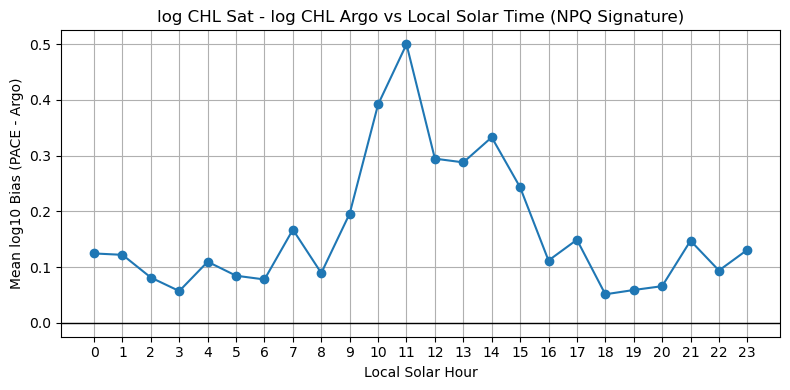

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================
#  CHL bias vs local solar time
# ============================

df = pd.read_parquet("tutorial_data/CHLA_argo_profile_Rss_chlor_a_Kd.parquet")
df = df.dropna(subset=["CHLA_0_10"])

df_bias = df.copy()

# --- Ensure datetime ---
df_bias['TIME'] = pd.to_datetime(df_bias['TIME'], utc=True, errors='coerce')

# --- Basic cleaning: drop rows missing key fields ---
df_bias = df_bias.dropna(subset=['TIME', 'LONGITUDE', 'CHLA_0_10', 'pace_chlor_a'])

# --- Remove non-positive CHL (can't take log10 of these) ---
df_bias = df_bias[(df_bias['CHLA_0_10'] > 0) & (df_bias['pace_chlor_a'] > 0)]

# --- Compute log10 CHL and bias (PACE - Argo) ---
eps = 1e-6  # tiny offset for numerical safety, but we already filtered <=0
df_bias['log_chl_argo'] = np.log10(df_bias['CHLA_0_10'] + eps)
df_bias['log_chl_sat'] = np.log10(df_bias['pace_chlor_a'] + eps)
df_bias['bias'] = df_bias['log_chl_sat'] - df_bias['log_chl_argo']

# --- Compute local solar time (approx) ---
# longitude in degrees east; 15° = 1 hour offset from UTC
df_bias['solar_hour'] = (df_bias['TIME'].dt.hour + df_bias['LONGITUDE'] / 15.0) % 24

# Bin into integer solar hours (0–23)
df_bias['solar_hour_bin'] = df_bias['solar_hour'].astype(int)

# --- Group by local solar hour and compute stats ---
bias_by_solar = df_bias.groupby('solar_hour_bin')['bias'].agg(['mean', 'median', 'std', 'count'])

#print("Bias (log10, PACE - Argo) by *local solar hour*:")
#display(bias_by_solar)

# --- Plot mean bias vs local solar hour ---
plt.figure(figsize=(8, 4))
plt.plot(bias_by_solar.index, bias_by_solar['mean'], '-o')
plt.axhline(0, color='k', lw=1)
plt.xlabel('Local Solar Hour')
plt.ylabel('Mean log10 Bias (PACE - Argo)')
plt.title('log CHL Sat - log CHL Argo vs Local Solar Time (NPQ Signature)')
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

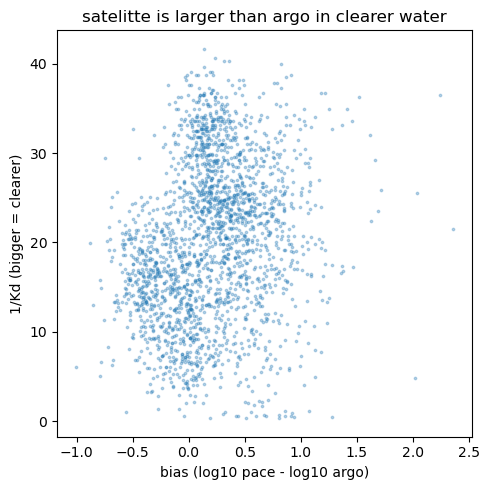

In [88]:
df = pd.read_parquet("tutorial_data/CHLA_argo_profile_Rss_chlor_a_Kd.parquet")
df = df.dropna(subset=["CHLA_0_10"])

df_bias = df.copy()

# --- Ensure datetime ---
df_bias['TIME'] = pd.to_datetime(df_bias['TIME'], utc=True, errors='coerce')

# --- Basic cleaning: drop rows missing key fields ---
df_bias = df_bias.dropna(subset=['TIME', 'LONGITUDE', 'CHLA_0_10', 'pace_chlor_a'])

# --- Remove non-positive CHL (can't take log10 of these) ---
df_bias = df_bias[(df_bias['CHLA_0_10'] > 0) & (df_bias['pace_chlor_a'] > 0)]

# --- Compute log10 CHL and bias (PACE - Argo) ---
eps = 1e-10  # tiny offset for numerical safety, but we already filtered <=0
df_bias['log_chl_argo'] = np.log10(df_bias['CHLA_0_10'] + eps)
df_bias['log_chl_sat'] = np.log10(df_bias['pace_chlor_a'] + eps)
df_bias['bias'] = df_bias['log_chl_sat'] - df_bias['log_chl_argo']

# Scatter plot
plt.figure(figsize=(5, 5))
plt.scatter(df_bias['bias'], 1/df_bias['pace_Kd_490'], s=3, alpha=0.3)

plt.xlabel("bias (log10 pace - log10 argo)")
plt.ylabel("1/Kd (bigger = clearer)")
plt.title("satelitte is larger than argo in clearer water")
plt.tight_layout()
plt.show()

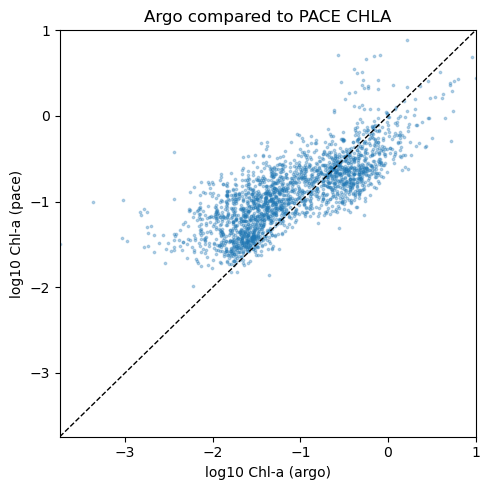

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_parquet("tutorial_data/CHLA_argo_profile_Rss_chlor_a_Kd.parquet")
df_clean = df.dropna(subset=["CHLA_0_10"])

# Take logs (natural log; use np.log10 if you prefer log10)
y_argo = df_clean["CHLA_0_10"].values
y_pace = df_clean["pace_chlor_a"].values

# Mask: positive & finite in both
mask = (
    np.isfinite(y_argo) &
    np.isfinite(y_pace) &
    (y_argo > 0) &
    (y_pace > 0)
)

y_argo = y_argo[mask]
y_pace = y_pace[mask]

y_argo = np.log10(y_argo)
y_pace = np.log10(y_pace)

# Scatter plot
plt.figure(figsize=(5, 5))
plt.scatter(y_argo, y_pace, s=3, alpha=0.3)

# 1:1 line
lims = [
    min(y_argo.min(), y_pace.min()),
    max(y_argo.max(), y_pace.max())
]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("log10 Chl-a (argo)")
plt.ylabel("log10 Chl-a (pace)")
plt.title("Argo compared to PACE CHLA")
plt.tight_layout()
plt.show()

## BBP700

In [25]:
# BBP700
# Load data from GitHub
df_y_name="BBP700"; df_lat_name="LATITUDE"; df_lon_name="LONGITUDE"; df_time_name="TIME"
import pandas as pd
base_url="https://raw.githubusercontent.com/fish-pace/2025-tutorials/main/tutorial_data/"
url = f"{base_url}argo_bgc_global_surface_{df_y_name}.parquet"
df = pd.read_parquet(url)

In [26]:
# BBP700
from pathlib import Path
import pandas as pd

results_dir = Path("data/matchups")
results_dir.mkdir(exist_ok=True)

all_batches = []
batch_size = 10
var = "bbp700"

for batch_idx, i in enumerate(range(0, len(results), batch_size), start=1):
    # If this batch was already done, skip it
    batch_path = results_dir / f"{var}_matchups_batch_{batch_idx:03d}.parquet"
    if batch_path.exists():
        print(f"  -> Skipping batch {batch_idx}, found {batch_path}")
        continue

    batch = results[i:i+batch_size]
    print(f"Batch {batch_idx}: {len(batch)} files")
        
    df_batch = run_batch(batch)  # returns a DataFrame

    # Save this batch immediately
    df_batch.to_parquet(batch_path, index=False)
    print(f"  -> Saved {len(df_batch)} rows to {batch_path}")


  -> Skipping batch 1, found data/matchups/bbp700_matchups_batch_001.parquet
  -> Skipping batch 2, found data/matchups/bbp700_matchups_batch_002.parquet
  -> Skipping batch 3, found data/matchups/bbp700_matchups_batch_003.parquet
  -> Skipping batch 4, found data/matchups/bbp700_matchups_batch_004.parquet
  -> Skipping batch 5, found data/matchups/bbp700_matchups_batch_005.parquet
  -> Skipping batch 6, found data/matchups/bbp700_matchups_batch_006.parquet
  -> Skipping batch 7, found data/matchups/bbp700_matchups_batch_007.parquet
  -> Skipping batch 8, found data/matchups/bbp700_matchups_batch_008.parquet
  -> Skipping batch 9, found data/matchups/bbp700_matchups_batch_009.parquet
  -> Skipping batch 10, found data/matchups/bbp700_matchups_batch_010.parquet
  -> Skipping batch 11, found data/matchups/bbp700_matchups_batch_011.parquet
  -> Skipping batch 12, found data/matchups/bbp700_matchups_batch_012.parquet
  -> Skipping batch 13, found data/matchups/bbp700_matchups_batch_013.par

In [ ]:
# When everything is done, you can merge all batches:
from pathlib import Path
import pandas as pd

var = "bbp700"
results_dir = Path("data/matchups")

batch_files = sorted(results_dir.glob(f"{var}_matchups_batch_*.parquet"))
dfs = [pd.read_parquet(f) for f in batch_files]
df_all = pd.concat(dfs, ignore_index=True)
df_all.to_parquet(f"tutorial_data/{var}_argo_rss_all.parquet", index=False)
rrs_cols = [c for c in df_all.columns if c.startswith("Rrs_")]
df_all_clean = df_all.dropna(subset=rrs_cols, how="all").reset_index(drop=True)
df_all_clean.to_parquet(f"tutorial_data/{var}_argo_rss.parquet", index=False)

In [5]:
print(f"Total rows: {len(df_all_clean)}")
print(f"Total rows: {len(df_all)}")


Total rows: 5599
Total rows: 29950


---------------------
## Testing stuff